# Proprioceptive sensing — object stiffness estimation

The hand squeezes a grasped object with the four fingers held at constant stiffness
$k_{\rm hold}$ = {K_TIP_HOLD} N/m (clamping side).  The thumb alone sweeps through
increasing tip stiffness levels and the resulting position–force finite difference
estimates object compliance without external force sensors.

---

## Why $\Delta x / \Delta F$ recovers $C_O$

At equilibrium, the VMC spring force equals the object reaction force.  Taking the
finite difference between the gentle baseline ($k_1$) and each probe level ($k_2 > k_1$):

$$\Delta x_\text{thumb} = x(k_2) - x(k_1), \qquad \Delta F_\text{thumb} = F(k_2) - F(k_1)$$

$$C_O = \frac{\|\Delta x_\text{thumb}\|}{\|\Delta F_\text{thumb}\|}$$

The hand compliance cancels exactly; lower $C_O$ means stiffer object.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import os, sys

sys.path.insert(0, os.path.join('../..'))
sys.path.insert(0, '.')
from hand_config import K_TIP_GENTLE, K_TIP_SWEEP, K_TIP_HOLD, N_RUNS, OBJECTS, FINGERTIPS

from plot_config import COLORS, FIG_W_SINGLE, FIG_W_DOUBLE  # style auto-applied

FIG_W = 10   # inches — change freely

FIG_H = 6    # inches — change freely

plt.rcParams['figure.figsize'] = [FIG_W, FIG_H]
GRID = True
plt.rcParams['axes.grid'] = GRID
)

OUTPUT_DIR = os.path.join('outputs', 'object_stiffness_hand')

K_TIP_GENTLE = float(K_TIP_GENTLE)
K_TIP_SWEEP  = [float(k) for k in K_TIP_SWEEP]

OBJECT_LABELS = ['Sphere', 'Sponge', 'Yarn']
OBJ_COLORS    = {'hard': '#D55E00', 'medium': '#E69F00', 'soft': '#56B4E9'}


def _sweep_plot(ax, per_run_dict, scale, obj):
    """Per-run dashed lines + mean solid + ±1 std band for one object."""
    k_levels = sorted(per_run_dict.keys())
    vals     = np.array([per_run_dict[k] * scale for k in k_levels])  # (n_k, n_runs)
    mean     = np.nanmean(vals, axis=1)
    std      = np.nanstd(vals,  axis=1)
    color    = OBJ_COLORS[obj]
    name     = OBJECT_LABELS[OBJECTS.index(obj)] if obj in OBJECTS else obj
    for r in range(vals.shape[1]):
        ax.plot(k_levels, vals[:, r], color=color, lw=1.0, linestyle='--', alpha=0.25)
    ax.fill_between(k_levels, mean - std, mean + std, color=color, alpha=0.15)
    ax.plot(k_levels, mean, color=color, label=name)

In [2]:
def load_runs(obj):
    """Load all run CSV files for an object; fall back to the single-file (video) naming."""
    dfs = []
    for r in range(1, N_RUNS + 1):
        p = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{obj}_run{r}.csv')
        if os.path.exists(p):
            dfs.append(pd.read_csv(p))
    if not dfs:
        p = os.path.join(OUTPUT_DIR, f'object_stiffness_hand_{obj}.csv')
        if os.path.exists(p):
            dfs.append(pd.read_csv(p))
    return dfs


def _thumb_baseline(df):
    gentle = df[df['k_tip_Npm'] == K_TIP_GENTLE]
    pos_b  = gentle[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
    F_b    = gentle[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
    return pos_b, F_b


def compliance_per_run(dfs):
    """Median-based C_O [m/N] for each run at each sweep level.
    Returns dict: k -> 1-D array of length n_runs."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        pos_b, F_b = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub  = df[df['k_tip_Npm'] == k]
            pos  = sub[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
            F1   = sub[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
            nF   = np.linalg.norm(F1 - F_b)
            out[k].append(np.linalg.norm(pos - pos_b) / nF if nF > 1e-12 else np.nan)
    return {k: np.array(v) for k, v in out.items()}


def displacement_per_run(dfs):
    """Median thumb displacement [m] from baseline per run at each sweep level."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        pos_b, _ = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub = df[df['k_tip_Npm'] == k]
            pos = sub[['tip_thumb_x_m', 'tip_thumb_y_m', 'tip_thumb_z_m']].median().to_numpy()
            out[k].append(np.linalg.norm(pos - pos_b))
    return {k: np.array(v) for k, v in out.items()}


def force_per_run(dfs):
    """Median thumb force change [N] from baseline per run at each sweep level."""
    out = {k: [] for k in K_TIP_SWEEP}
    for df in dfs:
        _, F_b = _thumb_baseline(df)
        for k in K_TIP_SWEEP:
            sub = df[df['k_tip_Npm'] == k]
            F1  = sub[['force_1st_thumb_x_N', 'force_1st_thumb_y_N', 'force_1st_thumb_z_N']].median().to_numpy()
            out[k].append(np.linalg.norm(F1 - F_b))
    return {k: np.array(v) for k, v in out.items()}


# ── Load data ──────────────────────────────────────────────────────────────────
data = {}
print('Loading data:')
for obj in OBJECTS:
    dfs = load_runs(obj)
    if not dfs:
        print(f'  {obj:<10s}: no data')
        continue
    data[obj] = dict(
        dfs        = dfs,
        compliance = compliance_per_run(dfs),
        displ      = displacement_per_run(dfs),
        force      = force_per_run(dfs),
    )
    print(f'  {obj:<10s}: {len(dfs)} run(s)')
    for k, vals in data[obj]['compliance'].items():
        run_strs = '  '.join(f'r{i+1}={v*1e3:.2f}' for i, v in enumerate(vals))
        print(f'    k={k:.0f} N/m  C_O [mm/N]: {run_strs}')

Loading data:
  hard      : 5 run(s)
    k=50 N/m  C_O [mm/N]: r1=11.55  r2=2.63  r3=6.46  r4=15.65  r5=3.40
    k=100 N/m  C_O [mm/N]: r1=21.00  r2=19.28  r3=22.14  r4=23.51  r5=19.76
    k=200 N/m  C_O [mm/N]: r1=21.26  r2=21.43  r3=26.56  r4=23.19  r5=21.49
  medium    : 5 run(s)
    k=50 N/m  C_O [mm/N]: r1=27.17  r2=25.16  r3=12.86  r4=22.73  r5=26.34
    k=100 N/m  C_O [mm/N]: r1=30.12  r2=34.24  r3=34.72  r4=33.94  r5=37.51
    k=200 N/m  C_O [mm/N]: r1=25.12  r2=28.22  r3=26.90  r4=27.65  r5=27.71
  soft      : 5 run(s)
    k=50 N/m  C_O [mm/N]: r1=36.19  r2=38.12  r3=22.53  r4=11.63  r5=6.68
    k=100 N/m  C_O [mm/N]: r1=49.44  r2=41.51  r3=39.47  r4=34.70  r5=29.48
    k=200 N/m  C_O [mm/N]: r1=32.30  r2=31.57  r3=28.32  r4=34.93  r5=34.06


## Thumb object compliance $C_O$ vs $k_{tip}$

$C_O = \|\Delta x_{\rm thumb}\| / \|\Delta F_{\rm thumb}\|$ — lower = stiffer object. Dashed lines = individual trials, solid = mean, band = ±1 std.

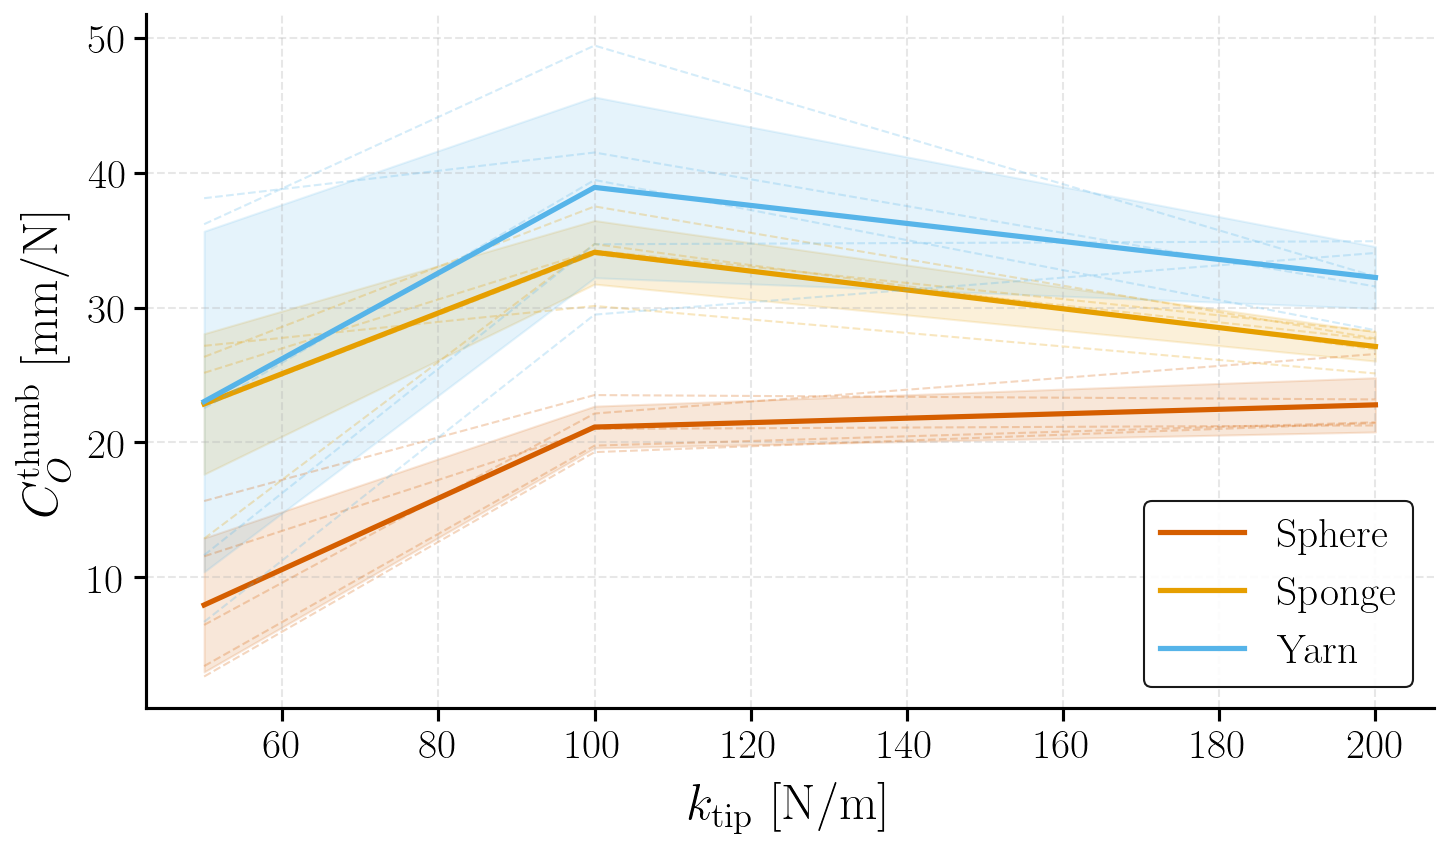

In [3]:
fig, ax = plt.subplots()
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['compliance'], 1e3, obj)
ax.set_xlabel(r'$k_\mathrm{tip}$ (N/m)')
ax.set_ylabel(r'$C_O^{\mathrm{thumb}}$ (mm/N)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_compliance_sweep.pdf'))
plt.show()

## Thumb tip displacement $\|\Delta x_{\rm thumb}\|$ vs $k_{tip}$

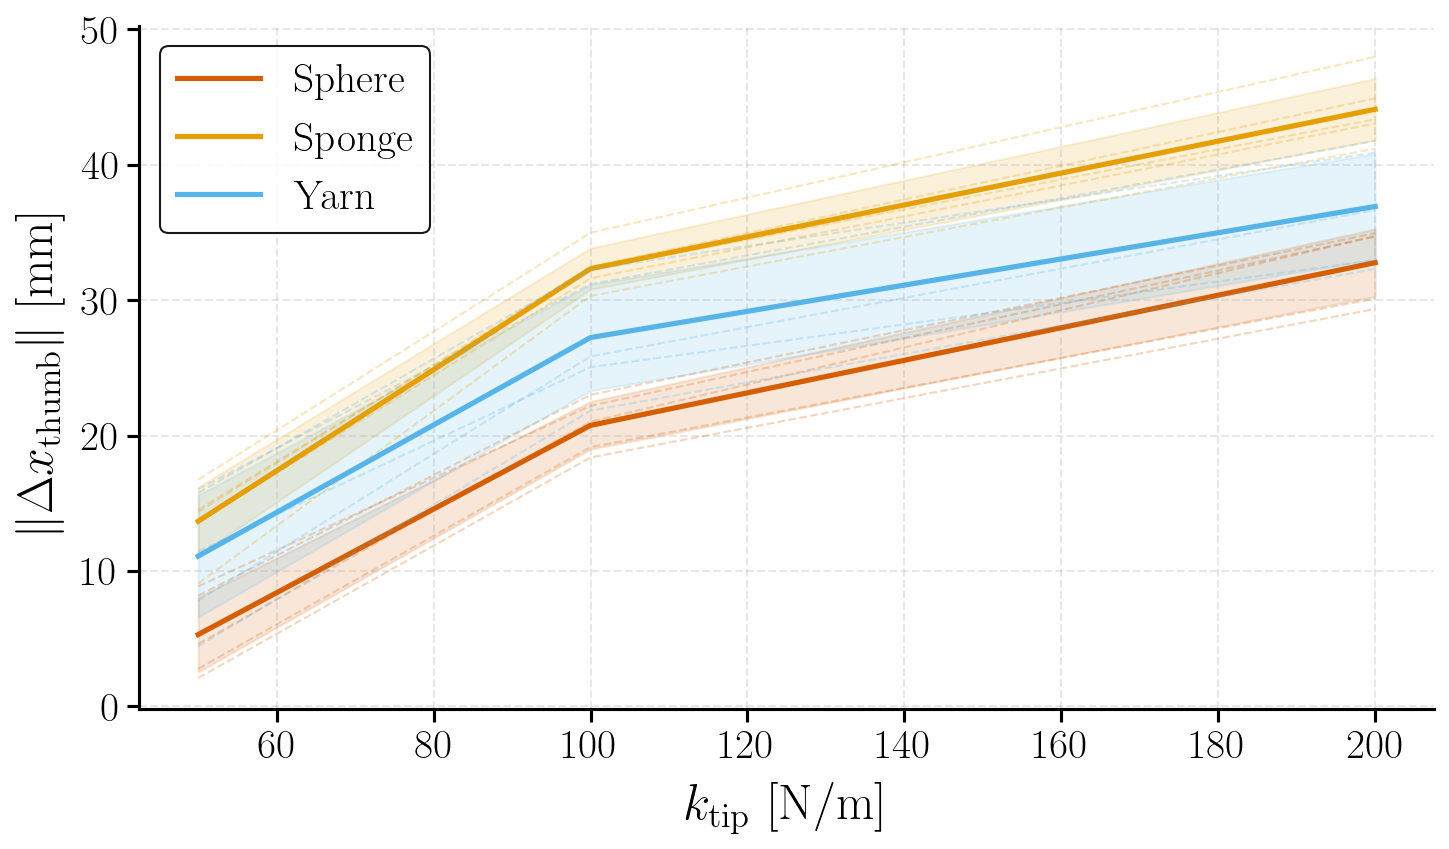

In [4]:
fig, ax = plt.subplots()
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['displ'], 1e3, obj)
ax.set_xlabel(r'$k_\mathrm{tip}$ (N/m)')
ax.set_ylabel(r'$\|\Delta x_{\mathrm{thumb}}\|$ (mm)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_displacement_sweep.pdf'))
plt.show()

## Thumb contact force $\|\Delta F_{\rm thumb}\|$ vs $k_{tip}$

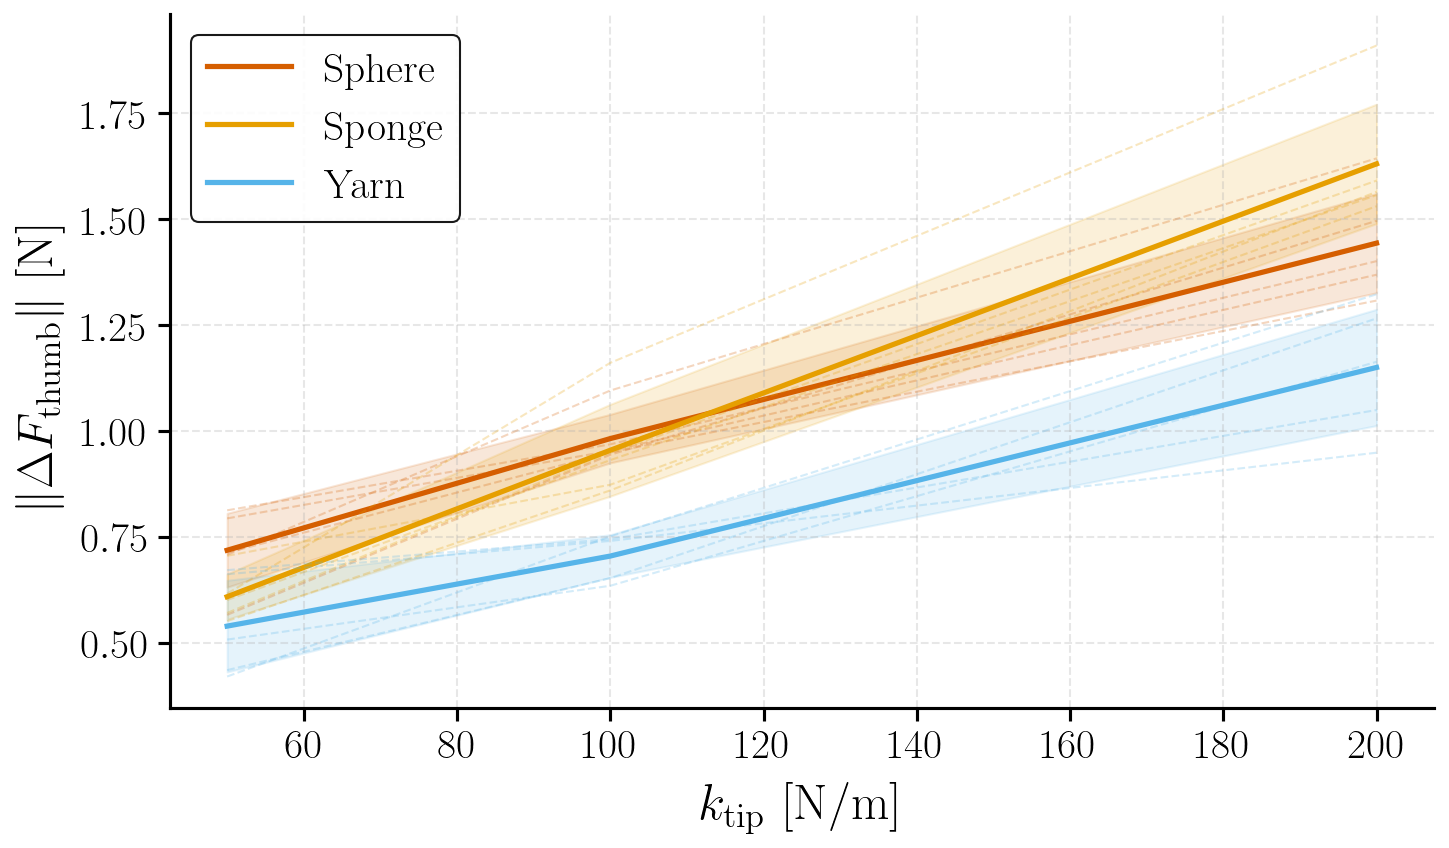

In [5]:
fig, ax = plt.subplots()
for obj in OBJECTS:
    if obj not in data:
        continue
    _sweep_plot(ax, data[obj]['force'], 1.0, obj)
ax.set_xlabel(r'$k_\mathrm{tip}$ (N/m)')
ax.set_ylabel(r'$\|\Delta F_{\mathrm{thumb}}\|$ (N)')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, 'thumb_force_sweep.pdf'))
plt.show()

## Object classification by thumb compliance

$C_O^{\mathrm{thumb}}$ at each $k_\mathrm{tip}$ — lower = stiffer. Dots = individual trials, filled marker = mean $\pm$ std.

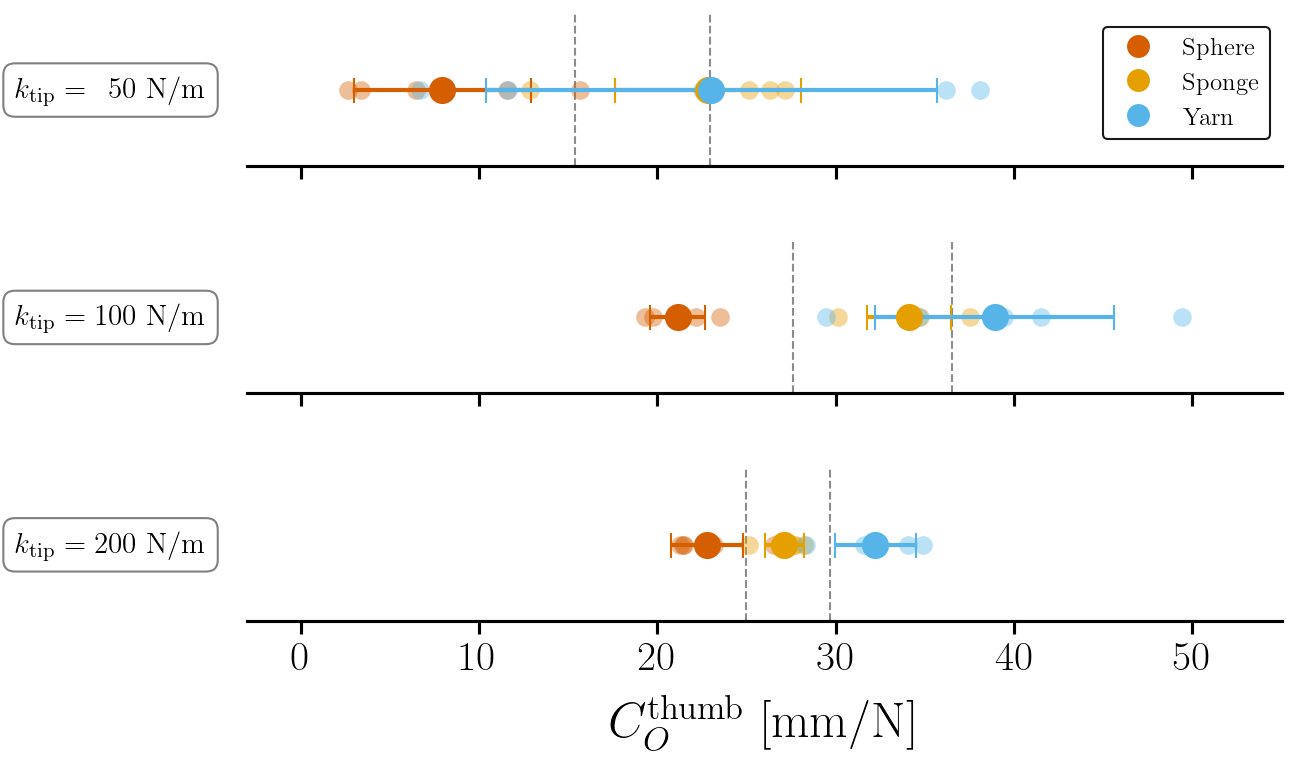


k_tip = 50 N/m
  Sphere      7.94 ± 4.970 mm/N
  Sponge      22.85 ± 5.215 mm/N
  Yarn        23.03 ± 12.635 mm/N

k_tip = 100 N/m
  Sphere      21.14 ± 1.550 mm/N
  Sponge      34.11 ± 2.360 mm/N
  Yarn        38.92 ± 6.703 mm/N

k_tip = 200 N/m
  Sphere      22.79 ± 2.011 mm/N
  Sponge      27.12 ± 1.086 mm/N
  Yarn        32.24 ± 2.294 mm/N


In [6]:
def _classification_subplot(ax, C_O_runs_local):
    sorted_objs = sorted(C_O_runs_local, key=lambda o: np.nanmean(C_O_runs_local[o]))
    stats = {obj: (float(np.nanmean(C_O_runs_local[obj])), float(np.nanstd(C_O_runs_local[obj])))
             for obj in sorted_objs}
    means      = [stats[o][0] for o in sorted_objs]
    thresholds = [(means[i] + means[i+1]) / 2 for i in range(len(means) - 1)]
    for obj in sorted_objs:
        vals  = C_O_runs_local[obj]
        m, s  = stats[obj]
        color = OBJ_COLORS[obj]
        ax.scatter(vals, np.zeros_like(vals), color=color, s=80, alpha=0.4, zorder=4, lw=0)
        ax.errorbar([m], [0], xerr=[[s], [s]],
                    fmt='o', color=color, ms=12, capsize=6, lw=2.0, zorder=5)
    for thr in thresholds:
        ax.axvline(thr, color='0.55', lw=1.0, linestyle='--')
    ax.set_yticks([])
    ax.spines[['left', 'top', 'right']].set_visible(False)
    ax.grid(False)
    return stats


conditions = [
    (k, {obj: data[obj]['compliance'][k] * 1e3
         for obj in OBJECTS if obj in data and k in data[obj]['compliance']})
    for k in K_TIP_SWEEP
]

n_cond = len(conditions)
fig, axes = plt.subplots(n_cond, 1, figsize=(10, 1.75 * n_cond), sharex=True)
if n_cond == 1:
    axes = [axes]

fig.subplots_adjust(left=0.28, right=0.97, hspace=0.5, top=0.95, bottom=0.18)

all_vals = [v for _, c in conditions for vals in c.values() for v in vals]
margin   = (max(all_vals) - min(all_vals)) * 0.12
xlim     = (min(all_vals) - margin, max(all_vals) + margin)

max_digits = len(str(int(max(K_TIP_SWEEP))))

results = []
for ax, (k, c_runs) in zip(axes, conditions):
    stats = _classification_subplot(ax, c_runs)
    ax.set_xlim(xlim)
    n_digits = len(str(int(k)))
    phantom  = r'\phantom{' + '0' * (max_digits - n_digits) + r'}' if n_digits < max_digits else ''
    ax.text(-0.04, 0.5,
            rf'$k_{{\mathrm{{tip}}}} = {phantom}{k:.0f}\ \mathrm{{N/m}}$',
            transform=ax.transAxes, ha='right', va='center', fontsize=14,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='0.5', lw=1.0),
            clip_on=False)
    results.append((k, c_runs, stats))

axes[-1].set_xlabel(r'$C_O^{\mathrm{thumb}}$ (mm/N)')

legend_handles = [
    mpl.lines.Line2D([0], [0], marker='o', color=OBJ_COLORS[obj],
                     linestyle='', ms=10, label=OBJECT_LABELS[OBJECTS.index(obj)])
    for obj in OBJECTS if obj in data
]
axes[0].legend(handles=legend_handles, loc='upper right', fontsize=12)

os.makedirs(OUTPUT_DIR, exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, 'object_classification.pdf'))
plt.show()

for k, c_runs, stats in results:
    print(f'\nk_tip = {k:.0f} N/m')
    for obj in sorted(c_runs, key=lambda o: np.nanmean(c_runs[o])):
        oi   = OBJECTS.index(obj)
        name = OBJECT_LABELS[oi] if oi < len(OBJECT_LABELS) else obj
        m, s = stats[obj]
        print(f'  {name:<10s}  {m:.2f} ± {s:.3f} mm/N')